In [1]:
# 📚 Core Libraries
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from torchvision.models import resnet18, ResNet18_Weights

# 📊 Evaluation & Visualization
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, mean_squared_error, accuracy_score

# ✅ Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cpu


In [2]:
# 1️⃣ Define Dual Output Model (KL + Ahlbäck)
class DualOutputCNN(nn.Module):
    def __init__(self):
        super(DualOutputCNN, self).__init__()
        self.features = resnet18(weights=ResNet18_Weights.DEFAULT)
        self.features.fc = nn.Identity()  # Remove final FC
        self.fc_kl = nn.Linear(512, 5)       # KL: 0–4
        self.fc_ahlback = nn.Linear(512, 5)  # Ahlbäck: 1–5 mapped to 0–4

    def forward(self, x):
        x = self.features(x)
        kl_out = self.fc_kl(x)
        ahl_out = self.fc_ahlback(x)
        return kl_out, ahl_out

# 2️⃣ Instantiate model
model = DualOutputCNN().to(device)

# 3️⃣ Image transforms
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

# 4️⃣ Dataset and Loader Setup
data_dir = r"C:\Users\Abhinav\Downloads\KL and Ahlback"
train_dataset = datasets.ImageFolder(os.path.join(data_dir, "train"), transform=transform)
val_dataset = datasets.ImageFolder(os.path.join(data_dir, "val"), transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

# 5️⃣ Class label mapping like ['0_1', '1_2', ...]
class_map = train_dataset.classes
print("Detected Classes:", class_map)


Detected Classes: ['0_1', '1_2', '2_3', '3_4', '4_5']


In [3]:
# 1️⃣ Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# 2️⃣ Training loop with early stopping + best model saving
num_epochs = 50
patience = 5
wait = 0
best_loss = float("inf")
train_losses = []

for epoch in range(num_epochs):
    model.train()
    total_loss = 0

    for imgs, labels in train_loader:
        imgs = imgs.to(device)

        kl_labels = torch.tensor([int(class_map[l].split("_")[0]) for l in labels]).to(device)
        ahl_labels = torch.tensor([int(class_map[l].split("_")[1]) - 1 for l in labels]).to(device)

        kl_out, ahl_out = model(imgs)
        loss_kl = criterion(kl_out, kl_labels)
        loss_ahl = criterion(ahl_out, ahl_labels)
        loss = loss_kl + loss_ahl

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    train_losses.append(avg_loss)
    print(f"📘 Epoch [{epoch+1}/{num_epochs}] - Train Loss: {avg_loss:.4f}")

    # 🔐 Save best model
    if avg_loss < best_loss:
        best_loss = avg_loss
        torch.save(model.state_dict(), "best_model.pth")
        print("✅ Best model saved.")
        wait = 0  # reset patience counter
    else:
        wait += 1
        print(f"⏳ No improvement. Patience counter: {wait}/{patience}")

    # ⛔ Early stop if no improvement for `patience` epochs
    if wait >= patience:
        print(f"🛑 Early stopping triggered after {epoch+1} epochs.")
        break

# 🔚 Final status
print(f"\n🎯 Best training loss: {best_loss:.4f}")


📘 Epoch [1/50] - Train Loss: 2.2261
✅ Best model saved.
📘 Epoch [2/50] - Train Loss: 1.5451
✅ Best model saved.
📘 Epoch [3/50] - Train Loss: 1.0781
✅ Best model saved.
📘 Epoch [4/50] - Train Loss: 0.6226
✅ Best model saved.
📘 Epoch [5/50] - Train Loss: 0.3404
✅ Best model saved.
📘 Epoch [6/50] - Train Loss: 0.1940
✅ Best model saved.
📘 Epoch [7/50] - Train Loss: 0.1201
✅ Best model saved.
📘 Epoch [8/50] - Train Loss: 0.1275
⏳ No improvement. Patience counter: 1/5
📘 Epoch [9/50] - Train Loss: 0.1150
✅ Best model saved.
📘 Epoch [10/50] - Train Loss: 0.1573
⏳ No improvement. Patience counter: 1/5
📘 Epoch [11/50] - Train Loss: 0.1621
⏳ No improvement. Patience counter: 2/5
📘 Epoch [12/50] - Train Loss: 0.0984
✅ Best model saved.
📘 Epoch [13/50] - Train Loss: 0.0856
✅ Best model saved.
📘 Epoch [14/50] - Train Loss: 0.0730
✅ Best model saved.
📘 Epoch [15/50] - Train Loss: 0.0891
⏳ No improvement. Patience counter: 1/5
📘 Epoch [16/50] - Train Loss: 0.0882
⏳ No improvement. Patience counter: 2


📊 Classification Report (KL Grades):
              precision    recall  f1-score   support

        KL 0      0.696     0.753     0.723       328
        KL 1      0.338     0.307     0.322       153
        KL 2      0.594     0.538     0.564       212
        KL 3      0.675     0.726     0.700       106
        KL 4      0.808     0.778     0.792        27

    accuracy                          0.613       826
   macro avg      0.622     0.620     0.620       826
weighted avg      0.604     0.613     0.607       826



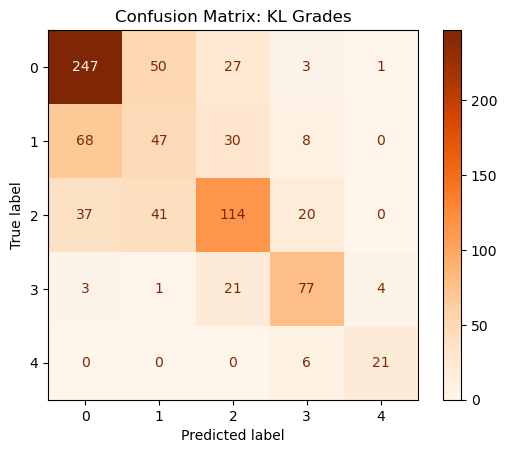

🎯 KL Accuracy: 61.26%
📏 KL MSE: 0.7288

📊 Classification Report (Ahlbäck Grades):
              precision    recall  f1-score   support

     Grade 1      0.696     0.753     0.723       328
     Grade 2      0.341     0.307     0.323       153
     Grade 3      0.591     0.538     0.563       212
     Grade 4      0.678     0.736     0.706       106
     Grade 5      0.840     0.778     0.808        27

    accuracy                          0.614       826
   macro avg      0.629     0.622     0.625       826
weighted avg      0.605     0.614     0.609       826



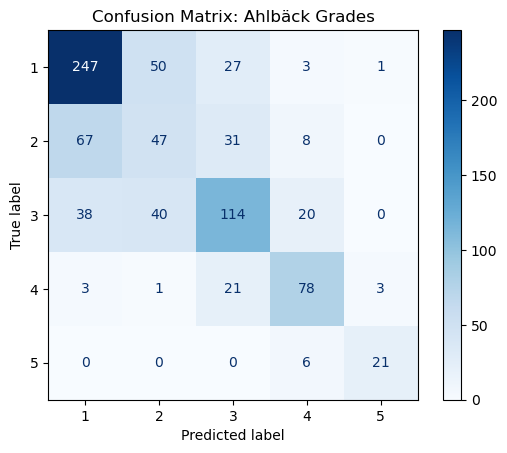

🎯 Ahlbäck Accuracy: 61.38%
📏 Ahlbäck MSE: 0.7312


In [2]:
import os
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torchvision.models import resnet18, ResNet18_Weights
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, mean_squared_error, accuracy_score
import matplotlib.pyplot as plt

# ✅ Define model class
class DualOutputCNN(nn.Module):
    def __init__(self):
        super(DualOutputCNN, self).__init__()
        self.features = resnet18(weights=ResNet18_Weights.DEFAULT)
        self.features.fc = nn.Identity()
        self.fc_kl = nn.Linear(512, 5)
        self.fc_ahlback = nn.Linear(512, 5)

    def forward(self, x):
        x = self.features(x)
        kl_out = self.fc_kl(x)
        ahl_out = self.fc_ahlback(x)
        return kl_out, ahl_out

# ✅ Setup device and reload model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = DualOutputCNN().to(device)
model.load_state_dict(torch.load("best_model.pth", map_location=device))
model.eval()

# ✅ Reload validation dataset
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])
data_dir = r"C:\Users\Abhinav\Downloads\KL and Ahlback"
val_dataset = datasets.ImageFolder(os.path.join(data_dir, "val"), transform=transform)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
class_map = val_dataset.classes

# ✅ Evaluate KL + Ahlbäck
true_kl, pred_kl = [], []
true_ahl, pred_ahl = [], []

with torch.no_grad():
    for imgs, labels in val_loader:
        imgs = imgs.to(device)
        kl_labels = torch.tensor([int(class_map[l].split("_")[0]) for l in labels]).to(device)
        ahl_labels = torch.tensor([int(class_map[l].split("_")[1]) - 1 for l in labels]).to(device)
        kl_out, ahl_out = model(imgs)
        kl_preds = kl_out.argmax(dim=1)
        ahl_preds = ahl_out.argmax(dim=1)
        true_kl.extend(kl_labels.cpu().numpy())
        pred_kl.extend(kl_preds.cpu().numpy())
        true_ahl.extend(ahl_labels.cpu().numpy())
        pred_ahl.extend(ahl_preds.cpu().numpy())

# 📊 KL Classification Report
print("\n📊 Classification Report (KL Grades):")
print(classification_report(true_kl, pred_kl, digits=3, target_names=[f"KL {i}" for i in range(5)]))
cm_kl = confusion_matrix(true_kl, pred_kl)
ConfusionMatrixDisplay(cm_kl, display_labels=[0, 1, 2, 3, 4]).plot(cmap=plt.cm.Oranges)
plt.title("Confusion Matrix: KL Grades")
plt.show()
print(f"🎯 KL Accuracy: {accuracy_score(true_kl, pred_kl)*100:.2f}%")
print(f"📏 KL MSE: {mean_squared_error(true_kl, pred_kl):.4f}")

# 📊 Ahlbäck Classification Report
print("\n📊 Classification Report (Ahlbäck Grades):")
print(classification_report(true_ahl, pred_ahl, digits=3, target_names=[f"Grade {i}" for i in range(1, 6)]))
cm_ahl = confusion_matrix(true_ahl, pred_ahl)
ConfusionMatrixDisplay(cm_ahl, display_labels=[1, 2, 3, 4, 5]).plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix: Ahlbäck Grades")
plt.show()
print(f"🎯 Ahlbäck Accuracy: {accuracy_score(true_ahl, pred_ahl)*100:.2f}%")
print(f"📏 Ahlbäck MSE: {mean_squared_error(true_ahl, pred_ahl):.4f}")


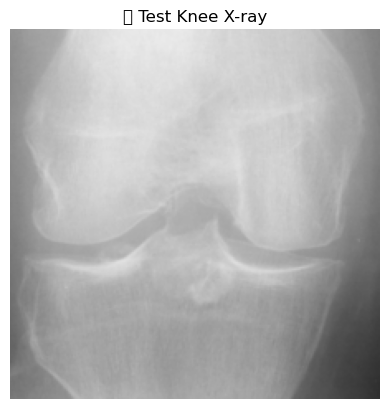

🧠 Predicted KL Grade: 2
🦴 Predicted Ahlbäck Grade: Grade 3
📏 Estimated Joint Space Width: 2.00 mm


In [5]:
from PIL import Image
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

# 🔍 Path to test image
test_img_path = r"C:\Users\Abhinav\Downloads\KL and Ahlback\test\2_3\9819871R.png"  # change path if needed

# 📥 Load and preprocess image
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

test_img = Image.open(test_img_path).convert("RGB")  # use RGB for ResNet
plt.imshow(test_img)
plt.axis("off")
plt.title("🦴 Test Knee X-ray")
plt.show()

input_tensor = transform(test_img).unsqueeze(0).to(device)

# 🔮 Predict
model.eval()
with torch.no_grad():
    kl_out, ahl_out = model(input_tensor)
    kl_pred = kl_out.argmax(dim=1).item()
    ahl_pred = ahl_out.argmax(dim=1).item() + 1  # Ahlbäck from 0→4 to Grade 1→5

# 📢 Show predictions
print(f"🧠 Predicted KL Grade: {kl_pred}")
print(f"🦴 Predicted Ahlbäck Grade: Grade {ahl_pred}")

# 📏 Simulated Joint Space Width (optional)
def kl_to_jsw(kl):
    # Fake mapping: more accurate if real regression model is trained
    mapping = {
        0: 4.0,
        1: 3.0,
        2: 2.0,
        3: 1.0,
        4: 0.5
    }
    return mapping.get(kl, 2.5)

predicted_jsw = kl_to_jsw(kl_pred)
print(f"📏 Estimated Joint Space Width: {predicted_jsw:.2f} mm")


C:\Users\Abhinav\AppData\Local\Temp\ipykernel_15724\2925468031.py:75: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


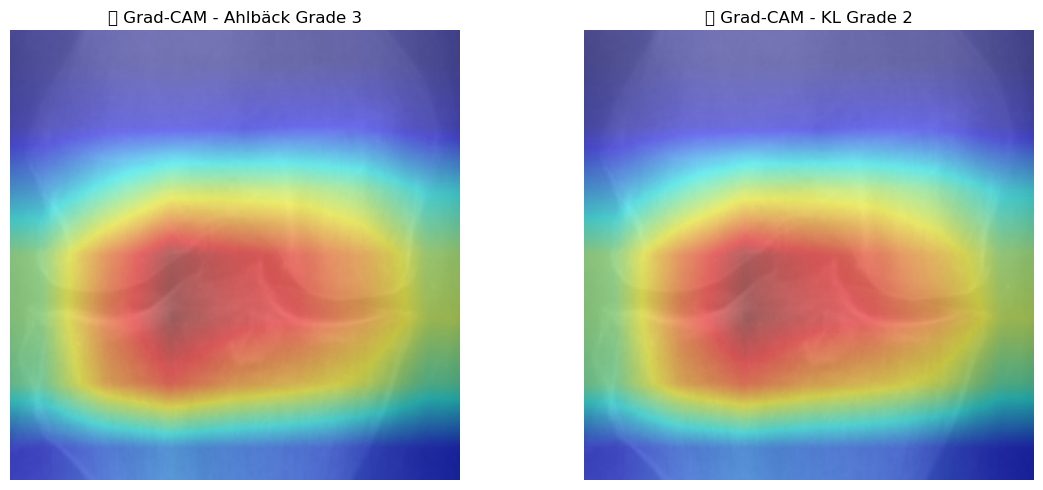

In [7]:
import cv2
import numpy as np
import torch.nn.functional as F

def generate_gradcam(model, image_tensor, target_layer, branch="ahlback", class_index=0):
    model.eval()
    gradients = []
    activations = []

    def backward_hook(module, grad_input, grad_output):
        gradients.append(grad_output[0])

    def forward_hook(module, input, output):
        activations.append(output)

    # Register hooks
    h_b = target_layer.register_backward_hook(backward_hook)
    h_f = target_layer.register_forward_hook(forward_hook)

    # Forward pass
    kl_out, ahl_out = model(image_tensor)

    # Select branch output
    target_output = ahl_out if branch == "ahlback" else kl_out
    target = target_output[:, class_index]
    model.zero_grad()
    target.backward()

    # Compute Grad-CAM
    grads = gradients[0].detach()
    acts = activations[0].detach()
    pooled_grads = torch.mean(grads, dim=[0, 2, 3])

    for i in range(acts.shape[1]):
        acts[:, i, :, :] *= pooled_grads[i]

    heatmap = acts.sum(dim=1).squeeze()
    heatmap = F.relu(heatmap)
    heatmap /= heatmap.max()

    heatmap = heatmap.cpu().numpy()
    heatmap = cv2.resize(heatmap, (224, 224))
    heatmap = np.uint8(255 * heatmap)
    heatmap_color = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    # Convert image tensor to displayable image
    img = image_tensor.squeeze().permute(1, 2, 0).cpu().numpy()
    img = np.uint8(255 * img)
    img = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)

    overlayed = cv2.addWeighted(img, 0.5, heatmap_color, 0.5, 0)

    h_b.remove()
    h_f.remove()

    return overlayed

# 🔥 Generate both Grad-CAMs
gradcam_ahlback = generate_gradcam(model, input_tensor, model.features.layer4, branch="ahlback", class_index=ahl_pred - 1)
gradcam_kl = generate_gradcam(model, input_tensor, model.features.layer4, branch="kl", class_index=kl_pred)

# 🖼️ Show both
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(gradcam_ahlback, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title(f"🔥 Grad-CAM - Ahlbäck Grade {ahl_pred}")

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(gradcam_kl, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title(f"🔥 Grad-CAM - KL Grade {kl_pred}")

plt.tight_layout()
plt.show()


In [8]:
def describe_joint_condition(kl_grade, ahlback_grade):
    symptoms = [
        "Pain during movement or after prolonged activity.",
        "Joint stiffness, especially in the morning.",
        "Swelling or warmth around the knee.",
        "Crackling or grinding sounds.",
        "Difficulty in bending or straightening the knee."
    ]

    # KL grading system descriptions
    kl_descriptions = {
        0: {
            "stage": "No signs of osteoarthritis",
            "treatment": ["Maintain healthy weight", "Stay active with low-impact exercises"],
            "precautions": ["Avoid high-impact sports"]
        },
        1: {
            "stage": "Doubtful joint space narrowing; possible osteophytes",
            "treatment": ["Physical therapy", "Light strengthening exercises"],
            "precautions": ["Avoid overuse and repetitive motion"]
        },
        2: {
            "stage": "Definite osteophytes and possible joint space narrowing",
            "treatment": ["NSAIDs for pain", "Activity modification", "Low-impact workouts"],
            "precautions": ["Monitor for worsening symptoms"]
        },
        3: {
            "stage": "Moderate joint space reduction; multiple osteophytes",
            "treatment": ["Injections (e.g. corticosteroids)", "Supportive devices", "Targeted rehab"],
            "precautions": ["Avoid climbing stairs", "Use joint support if needed"]
        },
        4: {
            "stage": "Severe joint space loss; large osteophytes and sclerosis",
            "treatment": ["Surgical consideration (e.g., knee replacement)", "Comprehensive pain management"],
            "precautions": ["Avoid weight-bearing stress", "Use mobility aids"]
        }
    }

    # Ahlbäck grading descriptions
    ahl_descriptions = {
        1: {
            "severity": "Grade I: Joint space narrowing without bone damage.",
            "treatment": ["Lifestyle change", "Anti-inflammatory meds", "Regular physiotherapy"],
            "precautions": ["Avoid high-impact activity"]
        },
        2: {
            "severity": "Grade II: Complete joint space loss, no bone collapse yet.",
            "treatment": ["Pain relief injections", "Custom braces", "ROM exercises"],
            "precautions": ["Minimize stair use", "Don't overload joint"]
        },
        3: {
            "severity": "Grade III: Bone loss less than 5 mm.",
            "treatment": ["Supportive devices", "Advanced rehab", "Pain management"],
            "precautions": ["No squatting/kneeling", "Monitor for collapse"]
        },
        4: {
            "severity": "Grade IV: Bone loss between 5–10 mm.",
            "treatment": ["Surgical consult", "Assistive walking tools"],
            "precautions": ["Schedule rest intervals", "Avoid prolonged standing"]
        },
        5: {
            "severity": "Grade V: Bone loss over 10 mm and joint deformity.",
            "treatment": ["Total knee replacement", "Post-surgery rehab", "Strong pain meds"],
            "precautions": ["Avoid risky movement", "Modify home environment"]
        }
    }

    print("🦴 Common Symptoms:")
    for s in symptoms:
        print(f"- {s}")

    print(f"\n📘 KL Grade {kl_grade} Interpretation:")
    print(f"• Stage: {kl_descriptions[kl_grade]['stage']}")
    print("• Treatment:")
    for t in kl_descriptions[kl_grade]['treatment']:
        print(f"  - {t}")
    print("• Precautions:")
    for p in kl_descriptions[kl_grade]['precautions']:
        print(f"  - {p}")

    print(f"\n📗 Ahlbäck Grade {ahlback_grade} Interpretation:")
    ahl_info = ahl_descriptions[ahlback_grade]
    print(f"• Severity: {ahl_info['severity']}")
    print("• Treatment:")
    for t in ahl_info['treatment']:
        print(f"  - {t}")
    print("• Precautions:")
    for p in ahl_info['precautions']:
        print(f"  - {p}")

# 📞 Call it using predictions from inference
describe_joint_condition(kl_pred, ahl_pred)


🦴 Common Symptoms:
- Pain during movement or after prolonged activity.
- Joint stiffness, especially in the morning.
- Swelling or warmth around the knee.
- Crackling or grinding sounds.
- Difficulty in bending or straightening the knee.

📘 KL Grade 2 Interpretation:
• Stage: Definite osteophytes and possible joint space narrowing
• Treatment:
  - NSAIDs for pain
  - Activity modification
  - Low-impact workouts
• Precautions:
  - Monitor for worsening symptoms

📗 Ahlbäck Grade 3 Interpretation:
• Severity: Grade III: Bone loss less than 5 mm.
• Treatment:
  - Supportive devices
  - Advanced rehab
  - Pain management
• Precautions:
  - No squatting/kneeling
  - Monitor for collapse
